In [ ]:
!pip install -q kagglehub pandas

In [ ]:
import kagglehub

# Tải phiên bản mới nhất của dataset
dataset_path = kagglehub.dataset_download(
    "aksahaha/crop-recommendation"
)

print("Dataset đã được tải về tại:")
print(dataset_path)

Using Colab cache for faster access to the 'crop-recommendation' dataset.
Dataset đã được tải về tại:
/kaggle/input/crop-recommendation


In [ ]:
import shutil
import os
import glob

# Tìm file csv
csv_file = glob.glob(os.path.join(dataset_path, "*.csv"))[0]

# Copy ra thư mục content
destination = "/content/Crop_recommendation.csv"

shutil.copy(csv_file, destination)

print("Đã copy tới:")
print(destination)

Đã copy tới:
/content/Crop_recommendation.csv


In [ ]:
import pandas as pd

df = pd.read_csv("/content/Crop_recommendation.csv")

df.head()

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label,Unnamed: 8,Unnamed: 9
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,NaN,NaN
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,NaN,NaN
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,NaN,NaN
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,NaN,NaN
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,NaN,NaN


# 1. Data Overview and Preprocessing

### Step 1: Read dataset

In [ ]:
display(df.head(10))
print(df.shape)

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label,Unnamed: 8,Unnamed: 9
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,NaN,NaN
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,NaN,NaN
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,NaN,NaN
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,NaN,NaN
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,NaN,NaN
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice,NaN,NaN
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice,NaN,NaN
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice,NaN,NaN
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice,NaN,NaN
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice,NaN,NaN


(2200, 10)


### Step 2: Check Null/Missing values

In [ ]:
print(df.isnull().sum())

Nitrogen          0
phosphorus        0
potassium         0
temperature       0
humidity          0
ph                0
rainfall          0
label             0
Unnamed: 8     2200
Unnamed: 9     2200
dtype: int64


### Step 3: Remove all unnecessary columns

In [ ]:
# remove null cols
new_df = df.drop(columns=['Unnamed: 8', 'Unnamed: 9'], axis=1, inplace=False)
print(new_df.isnull().sum())
print(new_df.shape)

Nitrogen       0
phosphorus     0
potassium      0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
(2200, 8)


### Step 4: View dtype of each feature

In [ ]:
print(new_df.dtypes)

Nitrogen         int64
phosphorus       int64
potassium        int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


# 2. Summary Statistics

In [ ]:
new_df.describe().round(2)

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


In [ ]:
new_df['label'].value_counts()
new_df['label'].nunique()

22

# 3. Feature Distribution

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

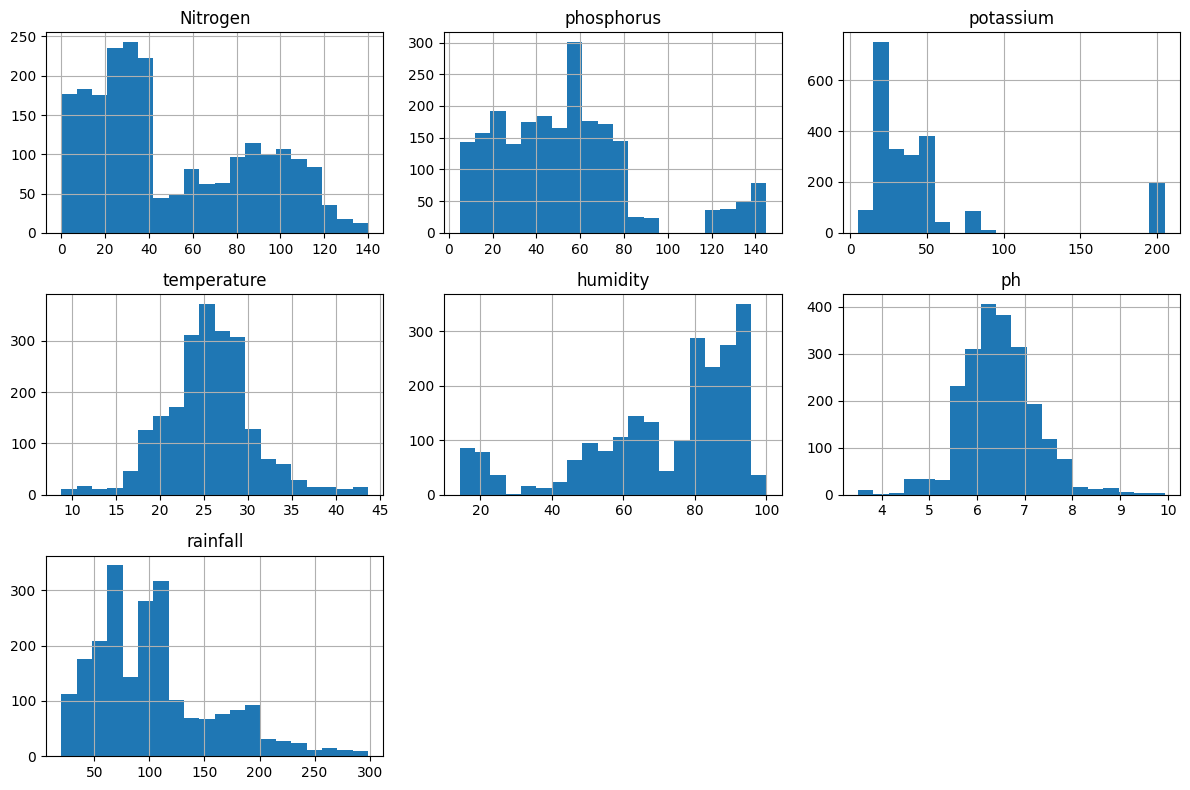

In [ ]:
new_df.hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

Interpretation:

*   Phosphorus and potassium exhibit have right-skewed distributions, heavily concentrated at lower values (0-50) but stretching to extreme maximums of 145 and 205, respectively. This shows that only a few specific crops demand high doses of these minerals.
*   Rainfall is right-skewed and unevenly distributed, heavily clustered around 50mm to 100mm. This shows that most crops thrive on low-to-moderate water levels, whereas a few outliers require heavy flooding.
*   Humidity is left-skewed, with data densely clustered at the higher end (80% to 100%) and a maximum of 99.98%, reflecting that most crops evaluated are tropical and depend on highly humid environments.
*  Temperature and pH show symmetrical, bell-shaped distributions. This demonstrates that the majority of crops share a similar, narrow comfort zone for temperature (around 25 °C) and soil pH (around 6.5).

Remarks:
*   The extreme maximums in skewed features (e.g., potassium reaching 205, rainfall reaching 298.56) will easily dominate and misleading distance calculations.





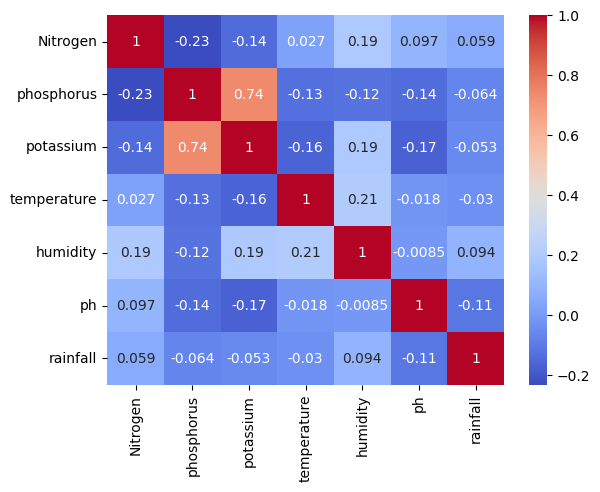

In [ ]:
sns.heatmap(
    new_df.drop('label', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [ ]:
grouped = new_df.groupby('label').mean().round(2)
print(grouped)

             Nitrogen  phosphorus  potassium  temperature  humidity    ph  \
label                                                                       
apple           20.80      134.22     199.89        22.63     92.33  5.93   
banana         100.23       82.01      50.05        27.38     80.36  5.98   
blackgram       40.02       67.47      19.24        29.97     65.12  7.13   
chickpea        40.09       67.79      79.92        18.87     16.86  7.34   
coconut         21.98       16.93      30.59        27.41     94.84  5.98   
coffee         101.20       28.74      29.94        25.54     58.87  6.79   
cotton         117.77       46.24      19.56        23.99     79.84  6.91   
grapes          23.18      132.53     200.11        23.85     81.88  6.03   
jute            78.40       46.86      39.99        24.96     79.64  6.73   
kidneybeans     20.75       67.54      20.05        20.12     21.61  5.75   
lentil          18.77       68.36      19.41        24.51     64.80  6.93   

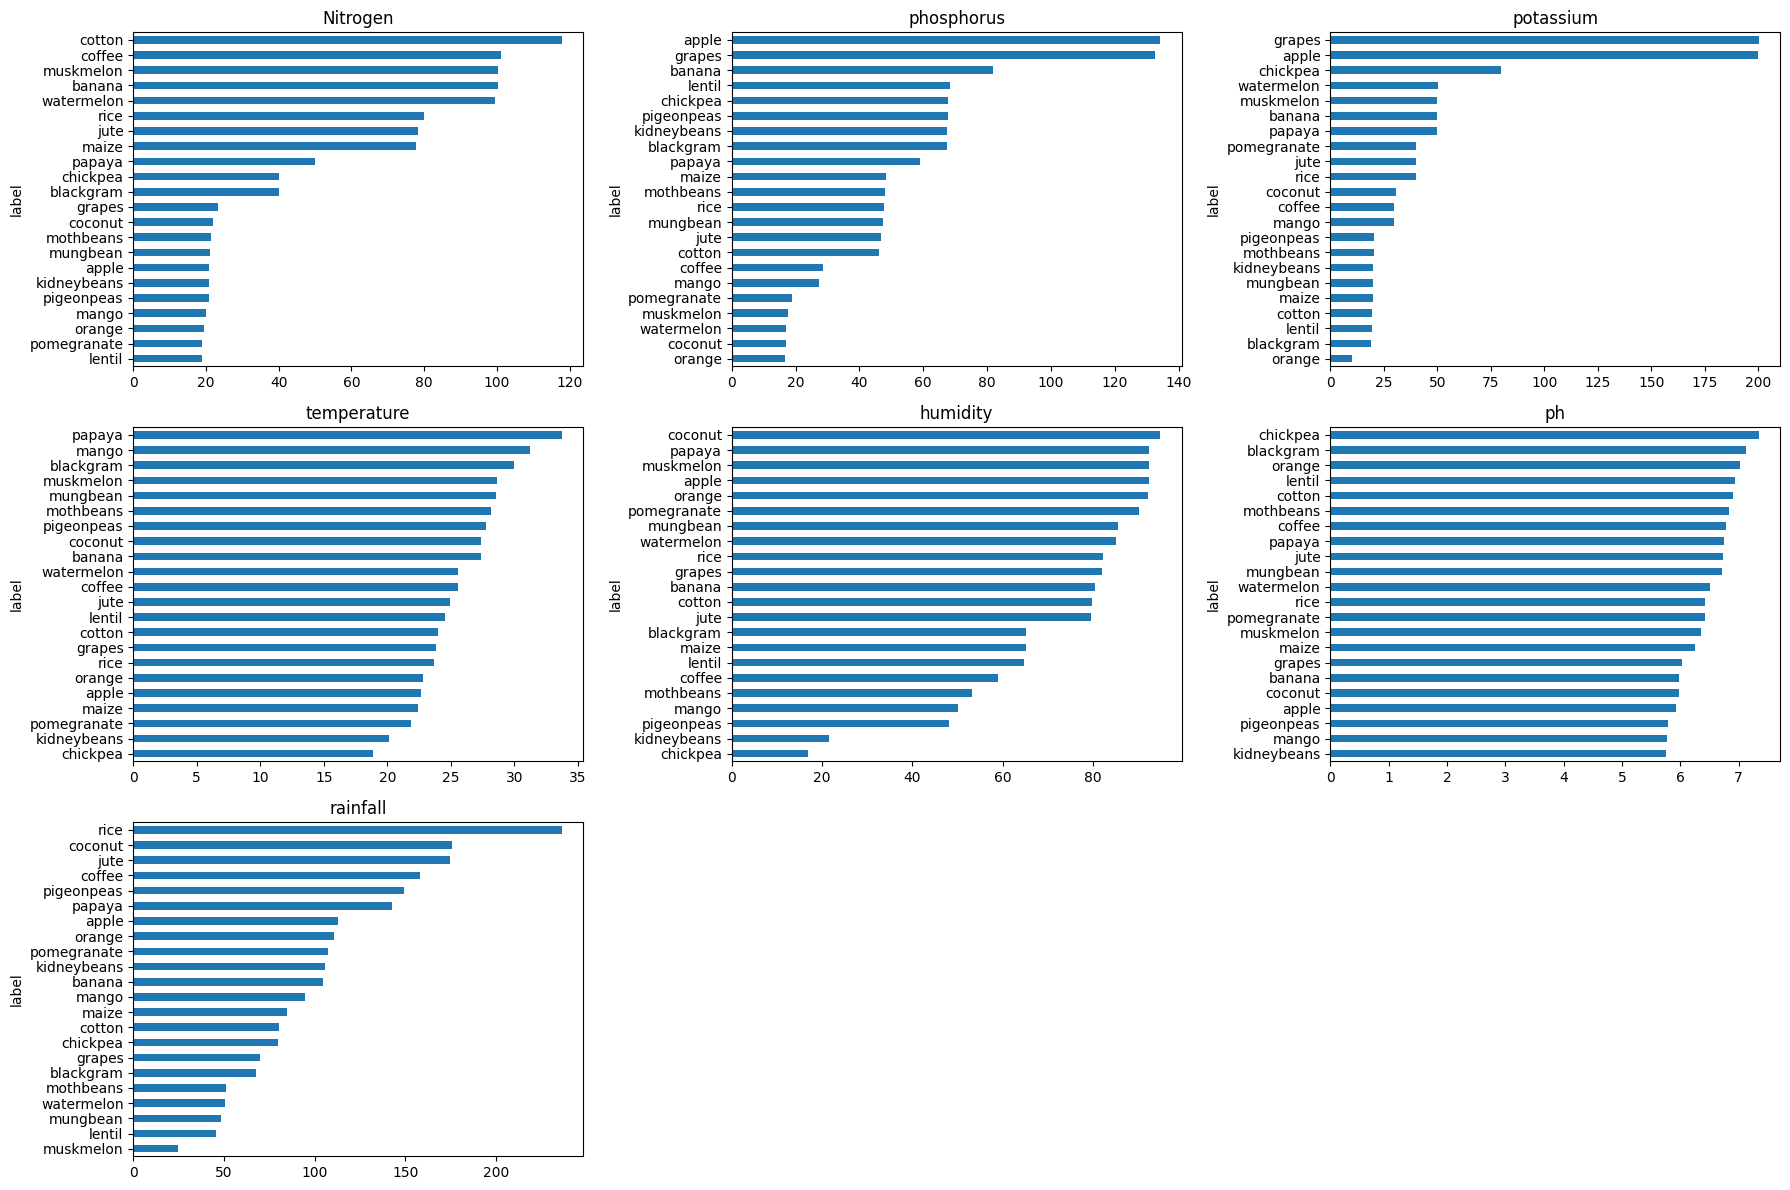

In [ ]:
features_barh = grouped.columns

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 12)
)

axes = axes.flatten()

for i, feature in enumerate(features_barh):
    grouped[feature].sort_values().plot(
        kind='barh',
        ax=axes[i],
        title=feature
    )
for i in range(len(features_barh), len(axes)):
  fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

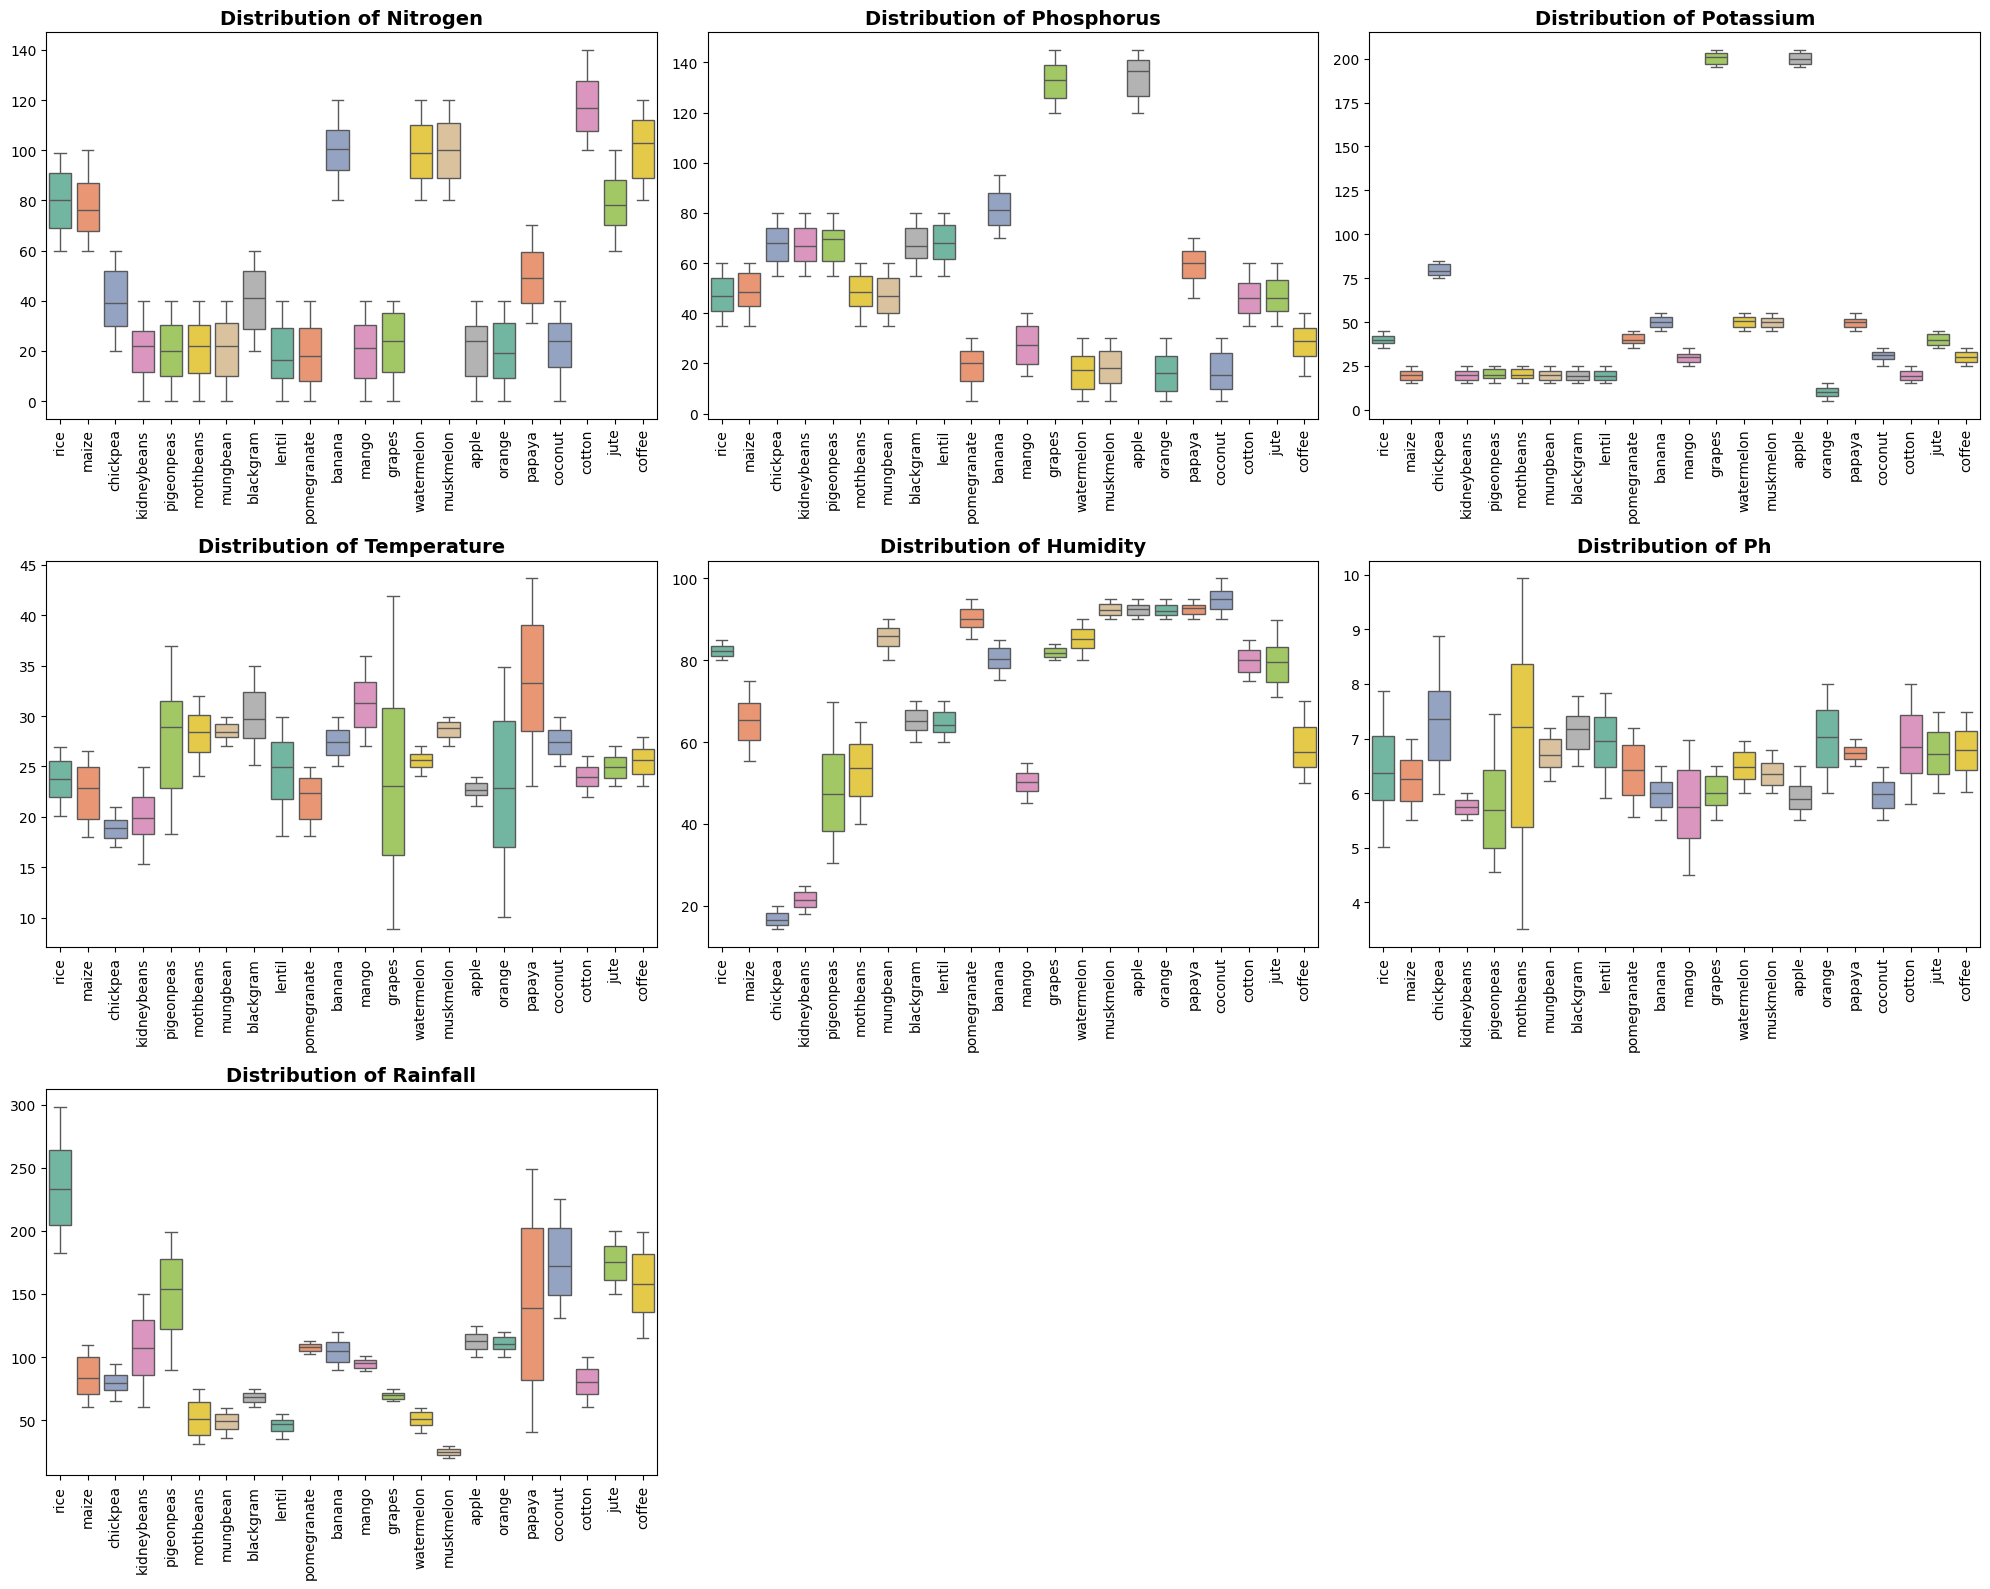

In [ ]:
features_boxplot = new_df.drop('label', axis=1).columns

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 16))
axes = axes.flatten()

for i, feature in enumerate(features_boxplot):
    sns.boxplot(x='label', y=feature, data=new_df, ax=axes[i], palette='Set2', hue='label', legend=False)

    axes[i].set_title(f'Distribution of {feature.capitalize()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=90)

for i in range(len(features_boxplot), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# 4. All Types of Distancess

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

feature_cols = ['Nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph', 'rainfall']
X = new_df[feature_cols].values
y = new_df['label'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

train_df = pd.DataFrame(X_train_raw, columns=feature_cols)
train_df['label'] = y_train
train_df.to_csv('/content/train.csv', index=False)

test_df = pd.DataFrame(X_test_raw, columns=feature_cols)
test_df['label'] = y_test
test_df.to_csv('/content/test.csv', index=False)

print(f"Đã lưu train.csv ({train_df.shape[0]} dòng) và test.csv ({test_df.shape[0]} dòng) vào /content/")


X_train: (1760, 7) | X_test: (440, 7)
Đã lưu train.csv (1760 dòng) và test.csv (440 dòng) vào /content/


**Giải thích từng dòng:**

- `train_test_split`, `StandardScaler`: import công cụ chia tập train/test và chuẩn hóa dữ liệu từ sklearn.
- `feature_cols`: danh sách 7 cột đặc trưng (không gồm `label`) dùng làm input cho mô hình.
- `X = new_df[feature_cols].values`: lấy dữ liệu đặc trưng dưới dạng mảng NumPy.
- `y = new_df['label'].values`: lấy nhãn (tên loại cây trồng) dưới dạng mảng NumPy.
- `train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)`: chia 80% dữ liệu để train, 20% để test; `stratify=y` đảm bảo tỷ lệ các lớp cây trồng trong tập train/test giống tỷ lệ gốc; `random_state=42` để kết quả tái lập được.
- `scaler = StandardScaler()`:
  - khởi tạo bộ chuẩn hóa (đưa mỗi đặc trưng về trung bình 0, độ lệch chuẩn 1)
  - z = (x-mean) / std
- `scaler.fit_transform(X_train_raw)`: học tham số chuẩn hóa (mean, std) từ tập train rồi áp dụng luôn lên tập train.
- `scaler.transform(X_test_raw)`: chỉ áp dụng (không học lại) tham số đã học từ train lên tập test, tránh rò rỉ dữ liệu (data leakage).

In [ ]:
print(train_df['label'].value_counts())
print(y)
print(y_train)

label
orange         80
grapes         80
kidneybeans    80
mothbeans      80
cotton         80
banana         80
lentil         80
mungbean       80
coffee         80
muskmelon      80
apple          80
blackgram      80
pigeonpeas     80
maize          80
rice           80
watermelon     80
jute           80
mango          80
pomegranate    80
papaya         80
coconut        80
chickpea       80
Name: count, dtype: int64
['rice' 'rice' 'rice' ... 'coffee' 'coffee' 'coffee']
['orange' 'grapes' 'kidneybeans' ... 'jute' 'jute' 'grapes']


### 4.1 Euclidean Distance

In [ ]:
def euclidean_distance(x1, x2):
    """Euclidean (L2) distance giữa 1 điểm x1 và 1 điểm/tập điểm x2."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    return np.sqrt(np.sum((x2 - x1) ** 2, axis=-1))

d = euclidean_distance(X_train[0], X_train[1])
print(f"Euclidean distance giữa sample 0 và sample 1: {d:.4f}")

Euclidean distance giữa sample 0 và sample 1: 5.3824


**Giải thích từng dòng:**

- `def euclidean_distance(x1, x2):`: hàm nhận vào 1 điểm `x1` và 1 điểm (hoặc tập điểm) `x2`.
- `np.asarray(..., dtype=float)`: ép kiểu về mảng NumPy số thực để tính toán vector hóa, tránh lỗi kiểu dữ liệu.
- `np.sum((x2 - x1) ** 2, axis=-1)`: lấy hiệu từng tọa độ giữa 2 điểm, bình phương, rồi cộng lại theo trục cuối (`axis=-1`) — cho phép `x2` là nhiều điểm cùng lúc (tính khoảng cách từ `x1` đến từng điểm trong `x2` mà không cần vòng lặp).
- `np.sqrt(...)`: lấy căn bậc hai — đúng công thức Euclidean: căn(tổng bình phương hiệu các tọa độ).
- Dòng `d = euclidean_distance(...)` và `print(...)`: demo tính khoảng cách Euclidean giữa 2 mẫu dữ liệu đầu tiên trong tập train để kiểm tra hàm hoạt động đúng.

### 4.2 Mahattan Distance

In [ ]:
def manhattan_distance(x1, x2):
    """Manhattan (L1) distance giữa 1 điểm x1 và 1 điểm/tập điểm x2."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    return np.sum(np.abs(x2 - x1), axis=-1)

d = manhattan_distance(X_train[0], X_train[1])
print(f"Manhattan distance giữa sample 0 và sample 1: {d:.4f}")

Manhattan distance giữa sample 0 và sample 1: 10.5589


**Giải thích từng dòng:**

- Cấu trúc hàm tương tự Euclidean, chỉ khác công thức tính.
- `np.abs(x2 - x1)`: lấy trị tuyệt đối của hiệu từng tọa độ (thay vì bình phương như Euclidean).
- `np.sum(..., axis=-1)`: cộng các trị tuyệt đối lại — đây chính là công thức Manhattan (L1): tổng khoảng cách đi theo từng trục, giống như đi bộ theo các ô vuông trong thành phố thay vì đi đường chéo.
- Phần demo bên dưới in ra khoảng cách Manhattan giữa 2 mẫu, dùng để so sánh với Euclidean.

### 4.3 Cosine Similarity

In [ ]:
def cosine_distance(x1, x2, eps=1e-10):
    """Cosine distance = 1 - cosine similarity giữa 1 điểm x1 và 1 điểm/tập điểm x2."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    dot = np.sum(x2 * x1, axis=-1)
    norm1 = np.linalg.norm(x1)
    norm2 = np.linalg.norm(x2, axis=-1)
    cosine_sim = dot / (norm1 * norm2 + eps)
    return 1 - cosine_sim

d = cosine_distance(X_train[0], X_train[1])
print(f"Cosine distance giữa sample 0 và sample 1: {d:.4f}")

# Gom cả 3 hàm vào 1 dict dùng chung cho KNN và KNN++
DISTANCE_FUNCS = {
    'euclidean': euclidean_distance,
    'manhattan': manhattan_distance,
    'cosine': cosine_distance,
}

def compute_distance(x1, x2, metric='euclidean'):
    if metric not in DISTANCE_FUNCS:
        raise ValueError(f"Unsupported metric: {metric}. Chọn 1 trong {list(DISTANCE_FUNCS)}")
    return DISTANCE_FUNCS[metric](x1, x2)

Cosine distance giữa sample 0 và sample 1: 1.2862


**Giải thích từng dòng:**

- `dot = np.sum(x2 * x1, axis=-1)`: tích vô hướng (dot product) giữa `x1` và từng điểm trong `x2`.
- `norm1 = np.linalg.norm(x1)`: độ dài (norm) của vector `x1`.
- `norm2 = np.linalg.norm(x2, axis=-1)`: độ dài của từng vector trong `x2`.
- `cosine_sim = dot / (norm1 * norm2 + eps)`: công thức cosine similarity = tích vô hướng chia cho tích độ dài 2 vector; `eps=1e-10` để tránh chia cho 0.
- `return 1 - cosine_sim`: chuyển similarity (càng gần 1 càng giống nhau) thành distance (càng gần 0 càng giống nhau) để đồng nhất cách dùng với 2 hàm khoảng cách trên.
- `DISTANCE_FUNCS`: dict gom cả 3 hàm lại theo tên, giúp gọi động bằng chuỗi (`'euclidean'`, `'manhattan'`, `'cosine'`) thay vì gọi trực tiếp tên hàm.
- `compute_distance(x1, x2, metric='euclidean')`: hàm wrapper dùng chung cho toàn bộ KNN/KNN++ phía sau — chỉ cần đổi tham số `metric` là đổi được công thức tính khoảng cách, kiểm tra hợp lệ bằng `if metric not in DISTANCE_FUNCS`.

# 5. KNN

In [ ]:
from collections import Counter
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class CustomKNN:
    def __init__(self, k=5, metric='euclidean'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y)
        return self

    def _predict_one(self, x):
        dists = compute_distance(x, self.X_train, metric=self.metric)
        k_idx = np.argsort(dists)[:self.k]
        k_labels = self.y_train[k_idx]
        return Counter(k_labels).most_common(1)[0][0]

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x) for x in X])


def evaluate_model(model, X_test, y_test, name=""):
    start = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"--- {name} ---")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Precision (macro) : {prec:.4f}")
    print(f"Recall (macro)    : {rec:.4f}")
    print(f"F1-score (macro)  : {f1:.4f}")
    print(f"Predict time      : {predict_time:.3f}s\n")

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "predict_time": predict_time, "y_pred": y_pred}

**Giải thích từng dòng:**

- `class CustomKNN:`: định nghĩa mô hình KNN tự cài đặt (không dùng sklearn).
- `__init__(self, k=5, metric='euclidean')`: lưu số láng giềng `k` và loại khoảng cách sẽ dùng.
- `fit(self, X, y)`: KNN không "học" tham số gì cả — chỉ đơn giản lưu lại toàn bộ tập train để so sánh khi dự đoán (gọi là "lazy learning").
- `_predict_one(self, x)`: dự đoán cho 1 điểm dữ liệu:
  - `compute_distance(x, self.X_train, metric=self.metric)`: tính khoảng cách từ điểm `x` đến **toàn bộ** các điểm trong tập train cùng lúc.
  - `np.argsort(dists)[:self.k]`: sắp xếp khoảng cách tăng dần, lấy chỉ số của `k` điểm gần nhất.
  - `Counter(k_labels).most_common(1)[0][0]`: đếm nhãn xuất hiện nhiều nhất trong `k` láng giềng gần nhất (bỏ phiếu đa số) — đó là nhãn dự đoán.
- `predict(self, X)`: lặp qua từng điểm trong `X` và gọi `_predict_one` cho từng điểm.
- `evaluate_model(...)`: hàm dùng chung để đánh giá bất kỳ mô hình nào (KNN hay KNN++):
  - Đo thời gian dự đoán (`time.time()` trước/sau).
  - Tính accuracy, precision, recall, F1 (đều lấy trung bình `macro` — coi mỗi loại cây trồng quan trọng như nhau, không thiên vị lớp có nhiều mẫu hơn).
  - In kết quả ra màn hình và trả về 1 dict chứa toàn bộ số liệu để dùng cho bảng so sánh sau này.

In [ ]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

k_values = [5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]
knn_sweep_results = []
knn_results = []
knn_models = {}

for metric in ['euclidean', 'manhattan', 'cosine']:
    for k in k_values:
        knn = CustomKNN(k=k, metric=metric)
        knn.fit(X_train, y_train)

        start = time.time()
        y_pred = knn.predict(X_test)
        predict_time = time.time() - start

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        row = {"model": f"KNN ({metric}, k={k})", "metric": metric, "k": k,
               "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
               "predict_time": predict_time, "y_pred": y_pred}
        knn_sweep_results.append(row)

        # Giữ lại đúng kết quả ở K=5 để mục 6 (so sánh KNN vs KNN++) chạy như cũ
        if k == 5:
            row_k5 = dict(row)
            row_k5["model"] = f"KNN ({metric})"
            knn_results.append(row_k5)
            knn_models[metric] = knn


metric,cosine,euclidean,manhattan
k,,,
5,0.9477,0.9818,0.9841
7,0.9477,0.9773,0.9818
9,0.9523,0.9773,0.9841
11,0.9568,0.9750,0.9795
13,0.9500,0.9818,0.9818
15,0.9386,0.9727,0.9773
17,0.9386,0.9682,0.9795
19,0.9318,0.9614,0.9773
21,0.9409,0.9523,0.9727


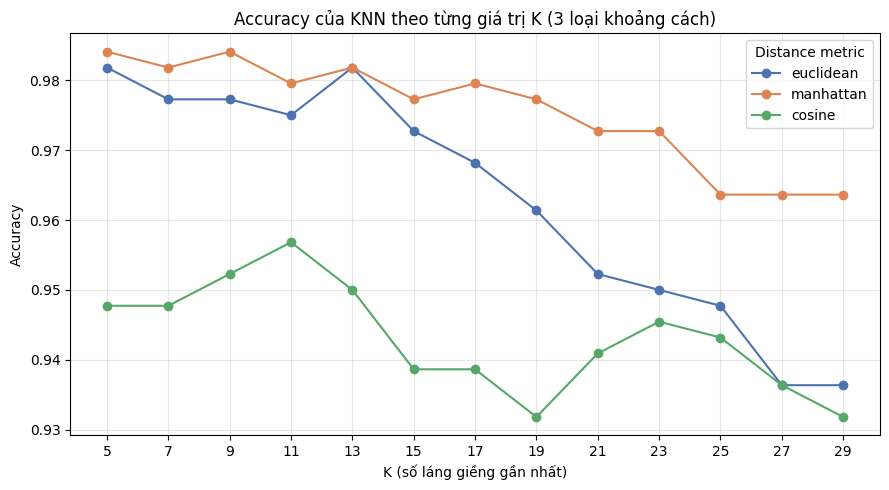

In [ ]:
knn_sweep_df = pd.DataFrame(knn_sweep_results)[["metric", "k", "accuracy", "precision", "recall", "f1", "predict_time"]]

# Bảng: mỗi hàng 1 giá trị K, mỗi cột 1 loại khoảng cách, giá trị là accuracy
pivot_k = knn_sweep_df.pivot(index="k", columns="metric", values="accuracy")
display(pivot_k.round(4))

plt.figure(figsize=(9, 5))
for metric, color in zip(['euclidean', 'manhattan', 'cosine'], ["#4C72B0", "#DD8452", "#55A868"]):
    subset = knn_sweep_df[knn_sweep_df["metric"] == metric].sort_values("k")
    plt.plot(subset["k"], subset["accuracy"], marker='o', label=metric, color=color)

plt.xlabel("K (số láng giềng gần nhất)")
plt.ylabel("Accuracy")
plt.title("Accuracy của KNN theo từng giá trị K (3 loại khoảng cách)")
plt.xticks(k_values)
plt.legend(title="Distance metric")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 6. KNN++

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

candidate_k = [5, 11, 22, 33, 44]
sil_scores = []
for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train)
    score = silhouette_score(X_train, km.labels_)
    sil_scores.append(score)
    print(f"n_clusters={k:3d} -> silhouette={score:.4f}")

best_n_clusters = candidate_k[int(np.argmax(sil_scores))]
print(f"\n=> Chọn n_clusters = {best_n_clusters}")


class KNNPlusPlus:
    def __init__(self, k=5, n_clusters=22, top_clusters=3, metric='euclidean', random_state=42):
        self.k = k
        self.n_clusters = n_clusters
        self.top_clusters = top_clusters
        self.metric = metric
        self.random_state = random_state

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y)
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        self.cluster_labels_ = self.kmeans.fit_predict(self.X_train)
        self.centroids_ = self.kmeans.cluster_centers_
        return self

    def _predict_one(self, x):
        centroid_dists = compute_distance(x, self.centroids_, metric=self.metric)
        nearest_clusters = np.argsort(centroid_dists)[:self.top_clusters]

        mask = np.isin(self.cluster_labels_, nearest_clusters)
        candidates_X = self.X_train[mask]
        candidates_y = self.y_train[mask]

        if len(candidates_X) < self.k:
            candidates_X = self.X_train
            candidates_y = self.y_train

        dists = compute_distance(x, candidates_X, metric=self.metric)
        k_idx = np.argsort(dists)[:self.k]
        k_labels = candidates_y[k_idx]
        return Counter(k_labels).most_common(1)[0][0]

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x) for x in X])

n_clusters=  5 -> silhouette=0.2855
n_clusters= 11 -> silhouette=0.3377
n_clusters= 22 -> silhouette=0.3376
n_clusters= 33 -> silhouette=0.3370
n_clusters= 44 -> silhouette=0.3082

=> Chọn n_clusters = 11


In [ ]:
knnpp_results = []
knnpp_models = {}

for metric in ['euclidean', 'manhattan', 'cosine']:
    knnpp = KNNPlusPlus(k=K, n_clusters=best_n_clusters, top_clusters=3, metric=metric)
    knnpp.fit(X_train, y_train)
    result = evaluate_model(knnpp, X_test, y_test, name=f"KNN++ ({metric})")
    knnpp_results.append(result)
    knnpp_models[metric] = knnpp

--- KNN++ (euclidean) ---
Accuracy          : 0.9750
Precision (macro) : 0.9767
Recall (macro)    : 0.9750
F1-score (macro)  : 0.9748
Predict time      : 0.281s

--- KNN++ (manhattan) ---
Accuracy          : 0.9795
Precision (macro) : 0.9811
Recall (macro)    : 0.9795
F1-score (macro)  : 0.9794
Predict time      : 0.783s

--- KNN++ (cosine) ---
Accuracy          : 0.9545
Precision (macro) : 0.9618
Recall (macro)    : 0.9545
F1-score (macro)  : 0.9538
Predict time      : 0.855s



In [ ]:
all_results = knn_results + knnpp_results
comparison_df = pd.DataFrame(all_results)[["model", "accuracy", "precision", "recall", "f1", "predict_time"]]
comparison_df["method"] = comparison_df["model"].apply(lambda s: "KNN++" if "++" in s else "KNN")
comparison_df["distance"] = comparison_df["model"].apply(lambda s: s.split('(')[1].strip(')'))
display(comparison_df.sort_values(["distance", "method"]).reset_index(drop=True))

,model,accuracy,precision,recall,f1,predict_time,method,distance
0,KNN (cosine),0.947727,0.952836,0.947727,0.946769,0.348989,KNN,cosine
1,KNN++ (cosine),0.954545,0.961789,0.954545,0.953845,0.854764,KNN++,cosine
2,KNN (euclidean),0.981818,0.982881,0.981818,0.981609,0.141717,KNN,euclidean
3,KNN++ (euclidean),0.975000,0.976735,0.975000,0.974817,0.281258,KNN++,euclidean
4,KNN (manhattan),0.984091,0.984848,0.984091,0.983958,0.259845,KNN,manhattan
5,KNN++ (manhattan),0.979545,0.981084,0.979545,0.979366,0.783439,KNN++,manhattan
